# 02 - Your First Neural Networks (regression and classification)

**Section:** ANNs | **Prereqs:** `GradientDesent.ipynb` | **Next:** `ANNs/MultilayerANNs.ipynb`

Two complete models, end to end. Part 1 fits a line with a tiny network
(regression, MSE loss). Part 2 separates two clouds of points (binary
classification, sigmoid + BCE loss). The code between them is nearly identical -
that similarity is the lesson.

**The four decisions behind every model**

| Decision | Regression (part 1) | Binary classification (part 2) |
|---|---|---|
| Final layer | `Linear(...,1)`, no activation | `Linear(...,1)` + `Sigmoid` |
| Loss | `MSELoss` | `BCELoss` |
| Output means | a number | probability of class 1 |
| Prediction | the output itself | `output > 0.5` |

**Also here:** the training loop (forward, loss, zero_grad, backward, step),
why `.detach()` is needed before plotting, and a repeated-runs experiment
showing that the *same* architecture and data can succeed or fail depending on
random initialisation.

In [15]:
# Standard imports for the whole course.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import torch

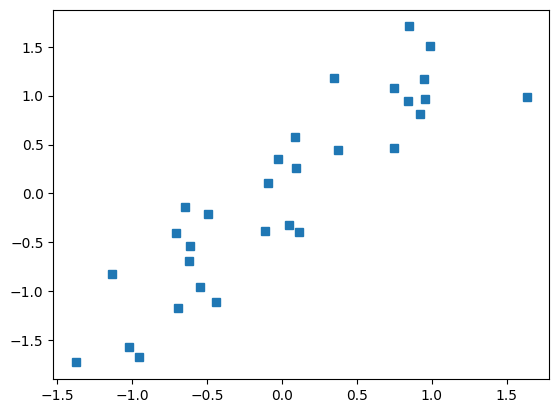

In [16]:
# Synthetic regression data: y = x + noise.
# Small and 1-dimensional on purpose - you can see the whole dataset at once.
x = torch.randn(30,1)

y = x + torch.randn(30,1)/2


plt.plot(x,y,'s');

In [17]:
# Both are (30,1), not (30,). PyTorch layers expect a 2D (samples, features)
# matrix; a bare 1D tensor is the single most common shape bug for beginners.
x.shape , y.shape

(torch.Size([30, 1]), torch.Size([30, 1]))

## Model Building

In [18]:
# nn.Sequential chains layers: output of one is input to the next.
# Linear(1,1) -> ReLU -> Linear(1,1).
# Careful: with only ONE unit in the hidden layer, if ReLU switches that unit
# off the model outputs a constant and can never recover ('dead ReLU').
# Re-run this notebook a few times and you will see it happen.
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(1,1),
    nn.ReLU(),
    nn.Linear(1,1)
)

model

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [19]:
# The other two ingredients:
#   MSELoss  - mean squared error, the default for regression,
#   SGD      - the optimizer, which owns model.parameters() and applies the
#              update rule from the gradient-descent notebook.
LearningRate = 0.05
lossFunc = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr = LearningRate)

In [20]:
# Pre-allocating the loss history is faster than appending, and lets us plot
# the learning curve afterwards - always plot it, it is the main diagnostic.
epochs = 500
losses = torch.zeros(epochs)

In [21]:
# THE TRAINING LOOP - the same five lines in every notebook of this course:
#   yhat = model(x)          forward pass: predictions from current weights
#   loss = lossFunc(yhat,y)  how wrong we are, as one differentiable number
#   optimizer.zero_grad()    clear last step's gradients (PyTorch ACCUMULATES
#                            them, so forgetting this silently sums gradients)
#   loss.backward()          autograd fills .grad on every parameter
#   optimizer.step()         apply the update rule (here: w -= lr * w.grad)
for epoch in range(epochs):

  #Forward Pass
  yHat = model(x)

  #compute Loss
  loss= lossFunc(yHat, y)
  losses[epoch] = loss

  #backprop
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

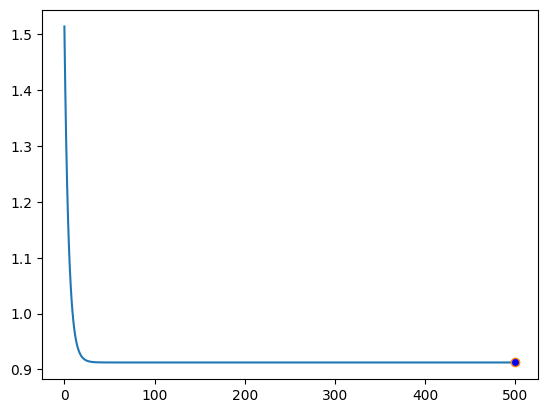

In [22]:
# Final forward pass for predictions, plus the loss recomputed by hand
# (mean of squared errors) to show MSELoss is nothing mysterious.
# .detach() strips the autograd graph so matplotlib gets a plain tensor.
# One for forward pass for predictions

predictions = model(x)

# compute loss
LossMSE = (y-predictions).pow(2).mean()

plt.plot(losses.detach(),markerfacecolor="red");
plt.plot(epochs,LossMSE.detach(),'o',markerfacecolor='Blue');

In [23]:
# Final loss value. Compare it against the loss curve above: they should agree.
LossMSE

tensor(0.9123, grad_fn=<MeanBackward0>)

/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


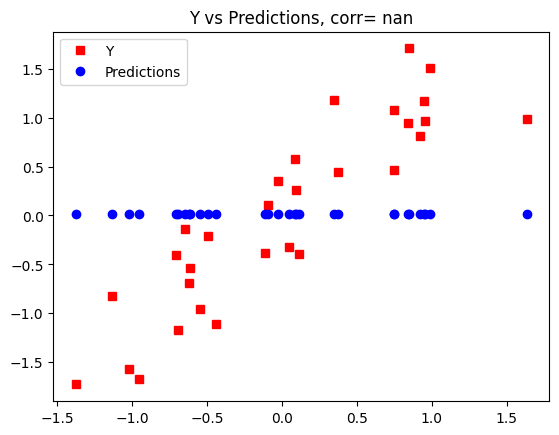

In [24]:
# Predictions vs truth. For regression, the correlation between them is the
# honest score - the raw MSE depends on the scale of y.
# Plotting data and predictions

plt.plot(x,y,'s',color="r",label="Y");
plt.plot(x,predictions.detach(),'o',color='b',label="Predictions");
plt.title(f"Y vs Predictions, corr= {np.corrcoef(y.T,predictions.detach().T)[0,1]:.2f}")
plt.legend();

# Code Challege

In [25]:
# Code challenge: does the model recover ANY slope m, or only positive ones?
# This helper makes a fresh dataset y = m*x + noise.
def init_params(m):
  x = torch.randn(50,1)

  y = m*x + torch.randn(50,1)/2

  return x,y




In [26]:
# One full experiment: random slope, fresh model, fresh optimizer, 200 epochs.
# Re-creating the model inside the function matters - reusing a trained model
# would leak the previous run's weights into the next experiment.
def train_model():
    m = np.linspace(-2,2,21)
    m = np.random.choice(m)

    x,y = init_params(m)

    model = nn.Sequential(
        nn.Linear(1,1),
        nn.ReLU(),
        nn.Linear(1,1)
    )

    lossFunc = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(),lr = 0.05)

    ephochs = 200
    losses = torch.zeros(200)

    for j in range(200):
      #forward pass
      yhat = model(x)

      # Calculate and update loss
      loss = lossFunc(yhat,y)
      losses[j] = loss

      # Backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


    predictions = model(x)

    return predictions,loss, x,y

In [ ]:
# Run the experiment 50 times and record final loss and correlation.
# (The commented-out block is the per-run plotting version, kept for reference.)
AllLosses = np.zeros(50)
allCorrs = np.zeros(50)

for i in range(50):
        pred, loss, x, y = train_model()
        x_np = x.detach().numpy()
        y_np = y.detach().numpy()
        pred_np = pred.detach().numpy()
        loss_np = loss.detach().numpy()
        AllLosses[i] = loss
        allCorrs[i] = np.corrcoef(y_np.flatten(), pred_np.flatten())[0, 1]     # # Create subplots
        # fig, ax = plt.subplots(2, 1, figsize=(10, 8))

        # # Convert tensors to numpy for plotting and correlation
        # x_np = x.detach().numpy()
        # y_np = y.detach().numpy()
        # pred_np = pred.detach().numpy()
        # loss_np = loss.detach().numpy()

        # # Calculate correlation coefficient
        # correlation = np.corrcoef(y_np.flatten(), pred_np.flatten())[0, 1]

        # # Plot data vs predictions
        # ax[0].scatter(x_np, y_np, color='r', alpha=0.6, label=f'True Data (m={true_m:.2f})')
        # ax[0].scatter(x_np, pred_np, color='b', alpha=0.6, label='Predictions')
        # ax[0].set_title(f'Experiment {i+1}: Data vs Predictions (Correlation: {correlation:.3f})')
        # ax[0].set_xlabel('X')
        # ax[0].set_ylabel('Y')
        # ax[0].legend()
        # ax[0].grid(True, alpha=0.3)

        # # Plot loss curve
        # ax[1].plot(loss_np, color="black", linewidth=2)
        # ax[1].set_title(f"Training Loss (Final: {loss_np[-1]:.4f})")
        # ax[1].set_xlabel('Epoch')
        # ax[1].set_ylabel('MSE Loss')
        # ax[1].grid(True, alpha=0.3)

        # plt.tight_layout()
        # plt.show()

        # print()
        # print()


In [ ]:
# The point of the experiment: performance is BIMODAL. Most runs correlate
# near 1, some collapse near 0 - same code, same data, different random init.
# Negative slopes fail most often, because the single ReLU unit dies.
# Lesson: never judge an architecture on one run.
fig , ax = plt.subplots(2,1)

ax[0].plot(AllLosses);
AllLosses

ax[1].plot(allCorrs);

# ANN Classification

In [ ]:
# Part 2 - binary classification.
# Same skeleton as the regression model, with one change: Sigmoid squashes the
# output to (0,1) so it can be read as P(class = 1).
ANNClassification = nn.Sequential(
    nn.Linear(2,1),
    nn.ReLU(),
    nn.Linear(1,1),
    nn.Sigmoid()
)

ANNClassification

In [ ]:
# Two Gaussian blobs ('qwerties'), labelled 0 and 1.
# blur controls the overlap: raise it and the classes become inseparable.
nPerClust = 100
blur = 1

A = [  1, 1 ]
B = [  5, 1 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [ ]:
# BCELoss = binary cross-entropy, the classification counterpart of MSE.
# It expects PROBABILITIES, which is exactly why the model ends in Sigmoid.
# (nn.BCEWithLogitsLoss takes raw scores instead and is numerically safer.)
lr = 0.2

lossFunc = nn.BCELoss()

optimizer = torch.optim.SGD(ANNClassification.parameters(),lr = lr)
optimizer

In [ ]:
# THE TRAINING LOOP - the same five lines in every notebook of this course:
#   yhat = model(x)          forward pass: predictions from current weights
#   loss = lossFunc(yhat,y)  how wrong we are, as one differentiable number
#   optimizer.zero_grad()    clear last step's gradients (PyTorch ACCUMULATES
#                            them, so forgetting this silently sums gradients)
#   loss.backward()          autograd fills .grad on every parameter
#   optimizer.step()         apply the update rule (here: w -= lr * w.grad)
#
# Identical to the regression loop above. Only the model, loss and data changed.
epochs = 10000
losses = torch.zeros(epochs)
for i in range(epochs):
  # Forward Prop
  yhat = ANNClassification(data)

  # Loss calculation
  loss = lossFunc(yhat, labels)
  losses[i] = loss

  # BackProp
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


In [ ]:
# From probability to decision: threshold at 0.5.
# The threshold is a choice, not a law - Model Evaluation/ARPF.ipynb shows how
# moving it trades precision against recall.

predictions = ANNClassification(data)

predlabels = predictions>.5


# find errors
misclassified = np.where(predlabels != labels)[0]

# total accuracy
totalacc = totalacc = 100-100*len(misclassified)/(2*nPerClust)

print('Final accuracy: %g%%' %totalacc)


In [ ]:
# Misclassified points (red x) sit where the two clouds overlap. A linear
# boundary cannot do better there; no amount of training will fix it.
# plot the labeled data
fig = plt.figure(figsize=(5,5))
plt.plot(data[misclassified,0] ,data[misclassified,1],'rx',markersize=12,markeredgewidth=3)
plt.plot(data[np.where(~predlabels)[0],0],data[np.where(~predlabels)[0],1],'bs')
plt.plot(data[np.where(predlabels)[0],0] ,data[np.where(predlabels)[0],1] ,'ko')

plt.legend(['Misclassified','blue','black'],bbox_to_anchor=(1,1))
plt.title(f'{totalacc}% correct')
plt.show()


In [ ]:
# The learning curve. A curve still descending at the end means 'train longer';
# a flat one from early on usually means the learning rate is too small.
plt.plot(losses.detach());